In [3]:
import matplotlib.pyplot as plt

from src.preprocessing.preprocess   import *

{'status': 'heavy', 'qr_codes': [CodeResult(type='QRCODE', content='https://q.me-qr.com/rmtmfu2a', bbox=(1445, 2015, 193, 193), polygon=[(1445, 2015), (1445, 2208), (1637, 2207), (1638, 2015)], quality=1, orientation='LEFT', raw_bytes=None)]}
IMAGE
 size : 1648 x 2249
 channels : 1
 dtype : uint8

DECISION
 label : HEAVY
 confidence : 0.0000
 recipe : grayscale, denoise, adaptive_threshold, deskew, autocrop, qr_detect, sharpen
 probs : {'SKIP': '0.000', 'HEAVY': '0.000', 'CLEAN': '0.000'}

METADATA
 status : heavy
 qr_count : 1

QR OBJECTS
 [1]
 type: QRCODE
 content: https://q.me-qr.com/rmtmfu2a
 bbox: (1445, 2015, 193, 193)
 polygon: [(1445, 2015), (1445, 2208), (1637, 2207), (1638, 2015)]
 quality: 1
 orientation: LEFT
 raw_bytes: None


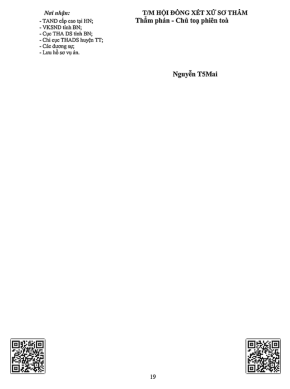

In [4]:
img = cv2.imread(r"C:\Users\kunnic\Desktop\VNDigitizeComprehensiveSystem_Team03\data\input\preprocess\images\0074.png")
pp = Preprocessing({
    "decide_engine": {"provider": None}
})

result = pp.process(img)

print(result.metadata)
print(result)

plt.imshow(result.image if result.image.ndim == 2 else cv2.cvtColor(result.image, cv2.COLOR_BGR2RGB), cmap="gray" if result.image.ndim == 2 else None)
plt.axis("off")
plt.show()

In [7]:
from ocr.tesseract import TesseractOCR
import pytesseract
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

ocr = TesseractOCR()
ocr_result = ocr.recognize(img)

print(ocr_result)

 OCR INFERENCE RESULT 
 Total Blocks : 51
 Confidence : 0.8988
--------------------------------------------------
 [00] [Conf: 0.6700] "Nơi" | Box: (280, 109, 56, 25)
 [01] [Conf: 0.9600] "nhận:" | Box: (346, 109, 88, 32)
 [02] [Conf: 0.7800] "T/M" | Box: (879, 107, 71, 43)
 [03] [Conf: 0.9300] "HỘI" | Box: (964, 103, 70, 39)
 [04] [Conf: 0.0000] "ĐÔNG" | Box: (1048, 103, 115, 31)
 [05] [Conf: 0.9600] "XÉT" | Box: (1176, 99, 77, 35)
 [06] [Conf: 0.9400] "XỬ" | Box: (1266, 99, 60, 35)
 [07] [Conf: 0.9600] "SƠ" | Box: (1336, 105, 51, 29)
 [08] [Conf: 0.8000] "THÂM" | Box: (1398, 103, 118, 31)
 [09] [Conf: 0.9300] "-" | Box: (253, 172, 8, 3)
 [10] [Conf: 0.9600] "TAND" | Box: (271, 159, 90, 22)
 [11] [Conf: 0.9500] "cấp" | Box: (372, 152, 44, 36)
 [12] [Conf: 0.9600] "cao" | Box: (426, 166, 44, 16)
 [13] [Conf: 0.9600] "tại" | Box: (480, 158, 31, 29)
 [14] [Conf: 0.9600] "HN;" | Box: (522, 159, 54, 27)
 [15] [Conf: 0.9500] "Thâm" | Box: (836, 152, 105, 29)
 [16] [Conf: 0.9300] "phán" | Bo

In [6]:
from ocr.paddle import Paddle

try:
    paddle_ocr = Paddle()
    paddle_result = paddle_ocr.recognize(img)
    print(paddle_result)
except Exception as e:
    print("PaddleOCR failed, falling back to Tesseract:", e)
    paddle_result = None

Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\kunnic\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\kunnic\.paddlex\official_models\en_PP-OCRv5_mobile_rec`.


WARN [PaddleOCR] (Unimplemented) ConvertPirAttribute2RuntimeAttribute not support [pir::ArrayAttribute<pir::DoubleAttribute>]  (at ..\paddle\fluid\framework\new_executor\instruction\onednn\onednn_instruction.cc:118)

PaddleOCR failed, falling back to Tesseract: (Unimplemented) ConvertPirAttribute2RuntimeAttribute not support [pir::ArrayAttribute<pir::DoubleAttribute>]  (at ..\paddle\fluid\framework\new_executor\instruction\onednn\onednn_instruction.cc:118)

